# Exercise 4B

In this exercise, you will learn how to use PCA for dimensionality reduction to visualize clusters and then run a clustering algorithm.

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [143]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame=True).frame

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [145]:
X = df.drop('target', axis=1)

1. Perform scaling `(10 pts)`

In [146]:
## put your answer here
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(569, 30)

2. Perform dimensionality reduction using PCA `(10 pts)`

In [147]:
## put your answer here
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

3. Get the total explained variance `(5 pts)`

In [148]:
## put your answer here
print(f"Total Explained Variance: {explained_variance.sum()}")

Total Explained Variance: 0.6324320765155944


4. Plot the explained variances of each principal component `(5 pts)`

Explained variance of PC1: 0.44272025607526366
Explained variance of PC2: 0.18971182044033078


Text(0, 0.5, 'Explained Variance')

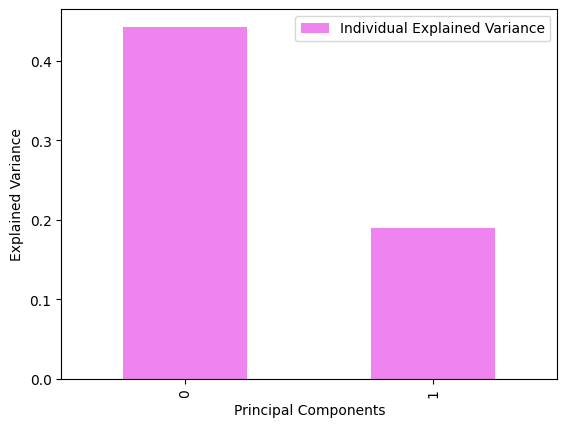

In [149]:
## put your answer here
explained_variance = pca.explained_variance_ratio_
y=0
for x in explained_variance:
  y = y+1
  print(f"Explained variance of PC{y}: {x}")

pd.DataFrame(explained_variance).plot.bar(color='violet')
plt.legend(['Individual Explained Variance'])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')

5. Visualize the dataset after PCA using a scatter plot `(5 pts)`

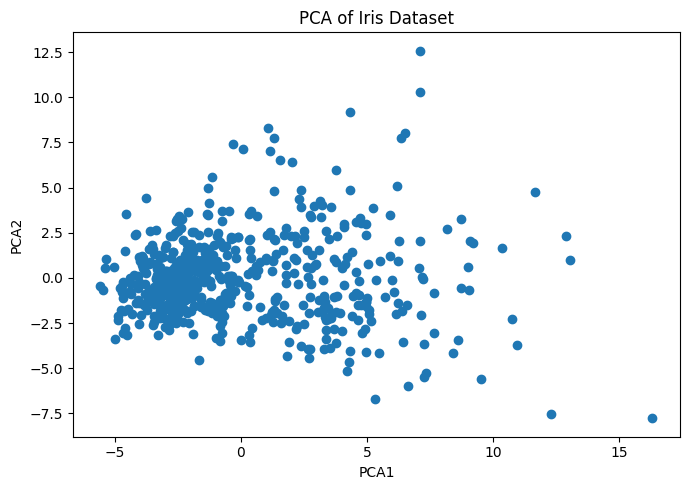

In [150]:
## put your answer here
plt.figure(figsize=(7,5))

# Scatter plot
plt.scatter(X_reduced[:,0],X_reduced[:,1])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA of Iris Dataset')
plt.tight_layout()

6. Perform clustering using any clustering algorithm `(10 pts)`

In [151]:
## put your answer here
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300,
                  n_init = 10, random_state = 0)
kmeans.fit(X_reduced)

labels = kmeans.labels_  # Cluster labels for each point
centroids = kmeans.cluster_centers_  # Cluster centroids



##Plotting the clustered data

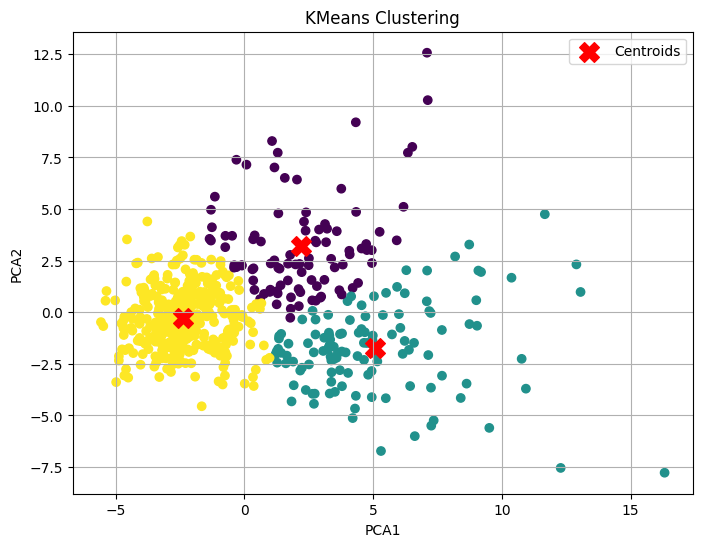

In [152]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, c='red', label='Centroids')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('KMeans Clustering')
plt.legend()
plt.grid(True)
plt.show()

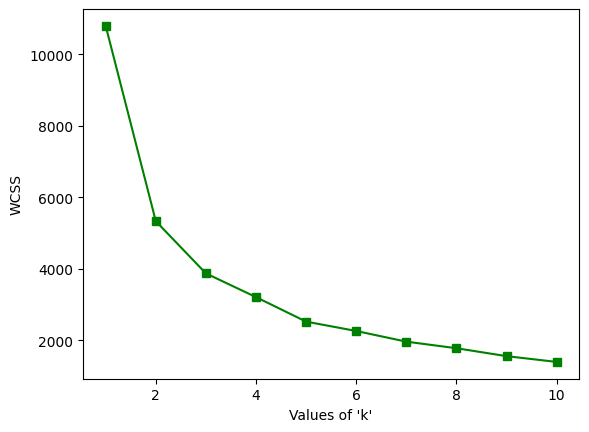

In [154]:
wcss = {}
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_reduced)
    wcss[i] = kmeans.inertia_

plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.xlabel("Values of 'k'")
plt.ylabel('WCSS')
plt.show()

7. View the loading scores of each principal component `(5 pts)`

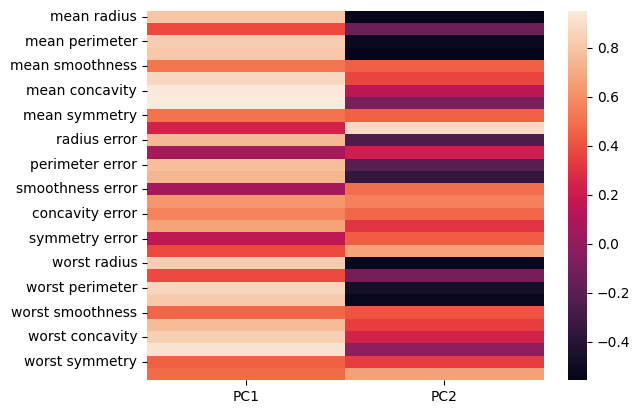

In [153]:
## put your answer here
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_matrix = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=df.columns.drop('target'))
loading_matrix



# Heat map
sns.heatmap(loading_matrix)
plt.show()